<a href="https://colab.research.google.com/github/FebrianArkaSamudra/PCVK_2025_FebrianArkaSamudra/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# 3. Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV)

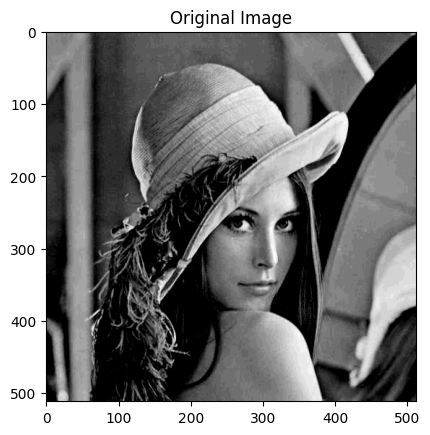

In [3]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_gs_lc2.jpg', cv.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.show()

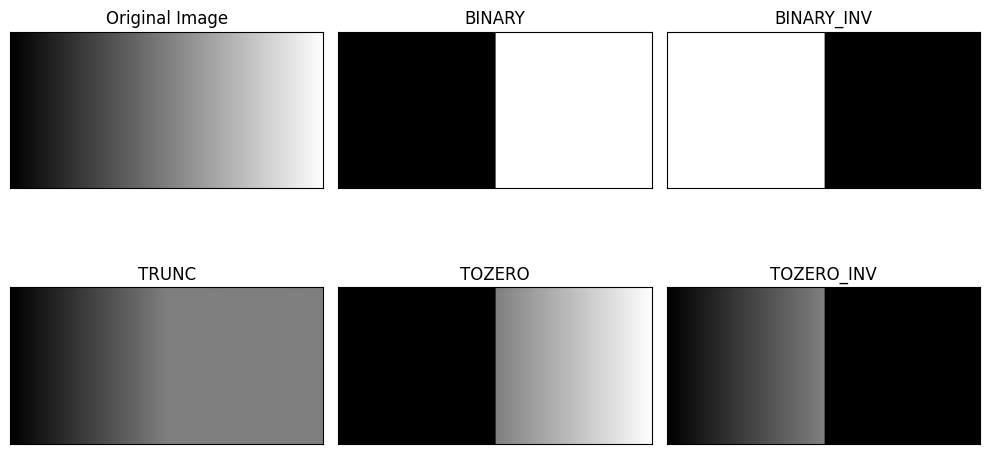

In [4]:
gradient = np.linspace(0, 255, 512, dtype=np.uint8)
gradient_img = np.tile(gradient, (256, 1))

T = 127
maxVal = 255

binary = np.where(gradient_img > T, maxVal, 0).astype(np.uint8)
binary_inv = np.where(gradient_img > T, 0, maxVal).astype(np.uint8)
trunc = np.where(gradient_img > T, T, gradient_img).astype(np.uint8)
tozero = np.where(gradient_img > T, gradient_img, 0).astype(np.uint8)
tozero_inv = np.where(gradient_img > T, 0, gradient_img).astype(np.uint8)

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [gradient_img, binary, binary_inv, trunc, tozero, tozero_inv]

plt.figure(figsize=(10,6))
for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

## 4. Otsu Thresholding

Otsu thresholding values (manual): 92


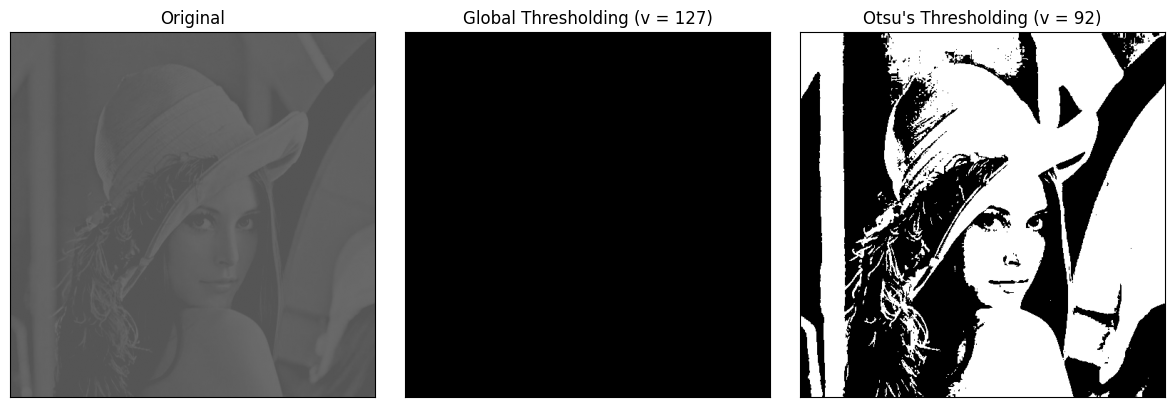

In [5]:
hist, bins = np.histogram(img.ravel(), 256, [0, 256])
total = img.size

sum_total = np.dot(np.arange(256), hist)
sumB, wB, max_var, otsu_T = 0, 0, 0, 0

for t in range(256):
    wB += hist[t]
    if wB == 0:
        continue
    wF = total - wB
    if wF == 0:
        break
    sumB += t * hist[t]
    mB = sumB / wB
    mF = (sum_total - sumB) / wF
    var_between = wB * wF * (mB - mF) ** 2
    if var_between > max_var:
        max_var = var_between
        otsu_T = t

print(f"Otsu thresholding values (manual): {otsu_T}")


T_global = 127
_, th_global = cv.threshold(img, T_global, 255, cv.THRESH_BINARY)
th_otsu_manual = np.where(img > otsu_T, 255, 0).astype(np.uint8)


titles = [
    'Original',
    f'Global Thresholding (v = {T_global})',
    f"Otsu\'s Thresholding (v = {otsu_T})"
]
images = [img, th_global, th_otsu_manual]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()


## 5. Histogram from a segmented imag

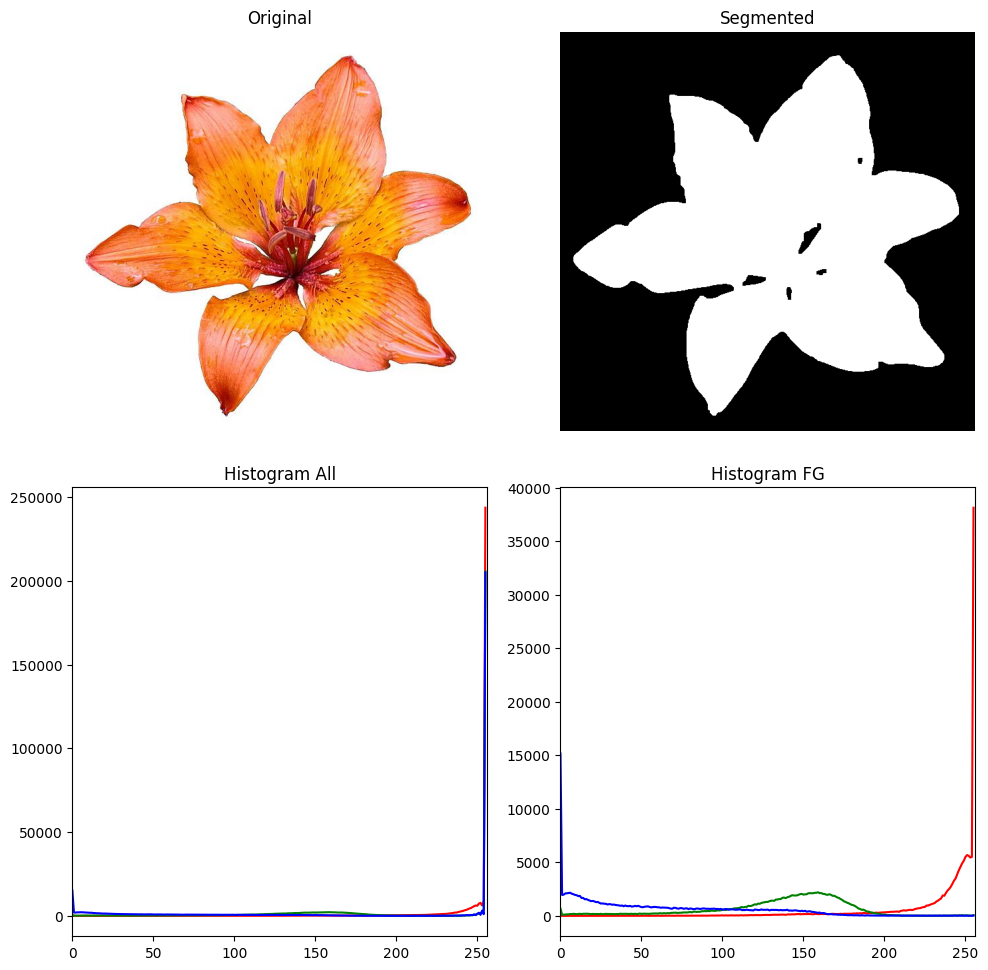

In [6]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lily.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
gray_blur = cv.GaussianBlur(gray, (5, 5), 0)

# Otsu Threshold
_, mask = cv.threshold(gray_blur, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=2)
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel, iterations=2)

# Segmented
segmented = cv.bitwise_and(img, img, mask=mask)

# Histogram all
hist_full_r = cv.calcHist([img], [0], None, [256], [0, 256])
hist_full_g = cv.calcHist([img], [1], None, [256], [0, 256])
hist_full_b = cv.calcHist([img], [2], None, [256], [0, 256])

# Histogram foreground
hist_fg_r = cv.calcHist([img], [0], mask, [256], [0, 256])
hist_fg_g = cv.calcHist([img], [1], mask, [256], [0, 256])
hist_fg_b = cv.calcHist([img], [2], mask, [256], [0, 256])

# Visualize
plt.figure(figsize=(10,10))

#Original & and segmented
plt.subplot(2,2,1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(mask, cmap='gray')
plt.title('Segmented')
plt.axis('off')

#histogram aal & FG
plt.subplot(2,2,3)
plt.plot(hist_full_r, color='r')
plt.plot(hist_full_g, color='g')
plt.plot(hist_full_b, color='b')
plt.title('Histogram All')
plt.xlim([0,256])

plt.subplot(2,2,4)
plt.plot(hist_fg_r, color='r')
plt.plot(hist_fg_g, color='g')
plt.plot(hist_fg_b, color='b')
plt.title('Histogram FG')
plt.xlim([0,256])

plt.tight_layout()
plt.show()

## 6. Perform color segmentation on the image "peppers.jpg", display only yellow colors . (Hint: you can use K-Means to display only certain colors)

Centroid Color (R,G,B):
Cluster 0: [252 250 248]
Cluster 1: [143  42  19]
Cluster 2: [176 131  82]
Cluster 3: [250 206   4]


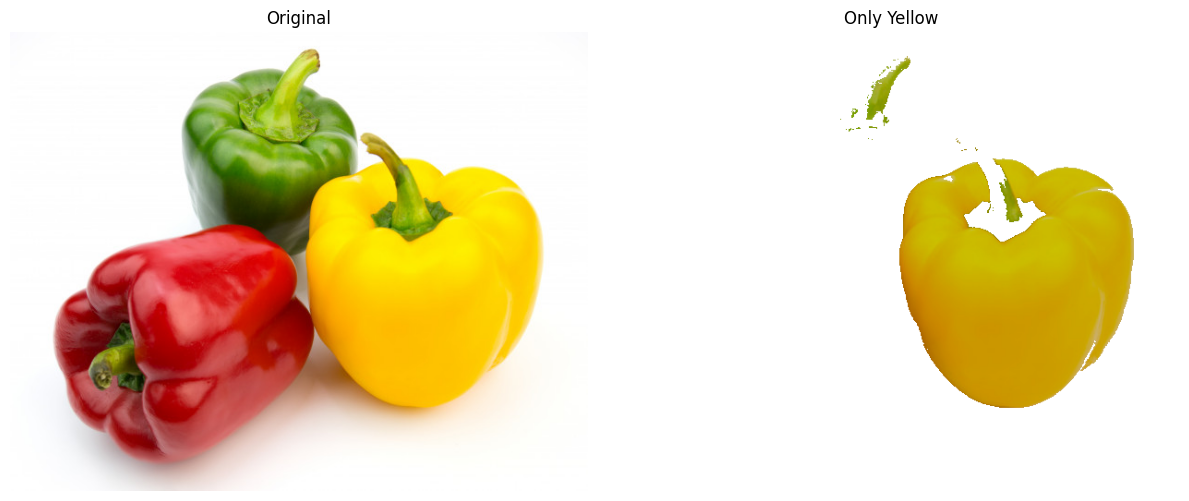

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 2D version
Z = img.reshape((-1, 3))
Z = np.float32(Z)

# K-Means
K = 4
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)

print("Centroid Color (R,G,B):")
for i, c in enumerate(centers):
    print(f"Cluster {i}: {c}")

# Cluster yellow
cluster_yellow = 3

# Masking yellow area
mask = (labels.flatten() == cluster_yellow)

# White Background
masked = np.ones_like(img, dtype=np.uint8) * 255
masked = masked.reshape((-1, 3))

# Original color & Shape
yellow_area = Z[mask] * 0.8
masked[mask] = yellow_area
masked = masked.reshape(img.shape).astype(np.uint8)

# Result
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(masked)
plt.title('Only Yellow')
plt.axis('off')

plt.tight_layout()
plt.show()

**Result** : When only the yellow color was shown, the yellow object almost disappeared because its RGB values were very bright and close to white, creating low contrast with the white background. This issue occurred due to the characteristics of the RGB color space and how K-Means calculates the average pixel colors. To fix this, the brightness of the yellow area was reduced or a darker background was used to improve contrast.

## 7. Open the crossword.jpg file. With the knowledge of thresholding that you have learned. Perform binary thresholding with the best results in your opinion. Copy the code and image results in this module.

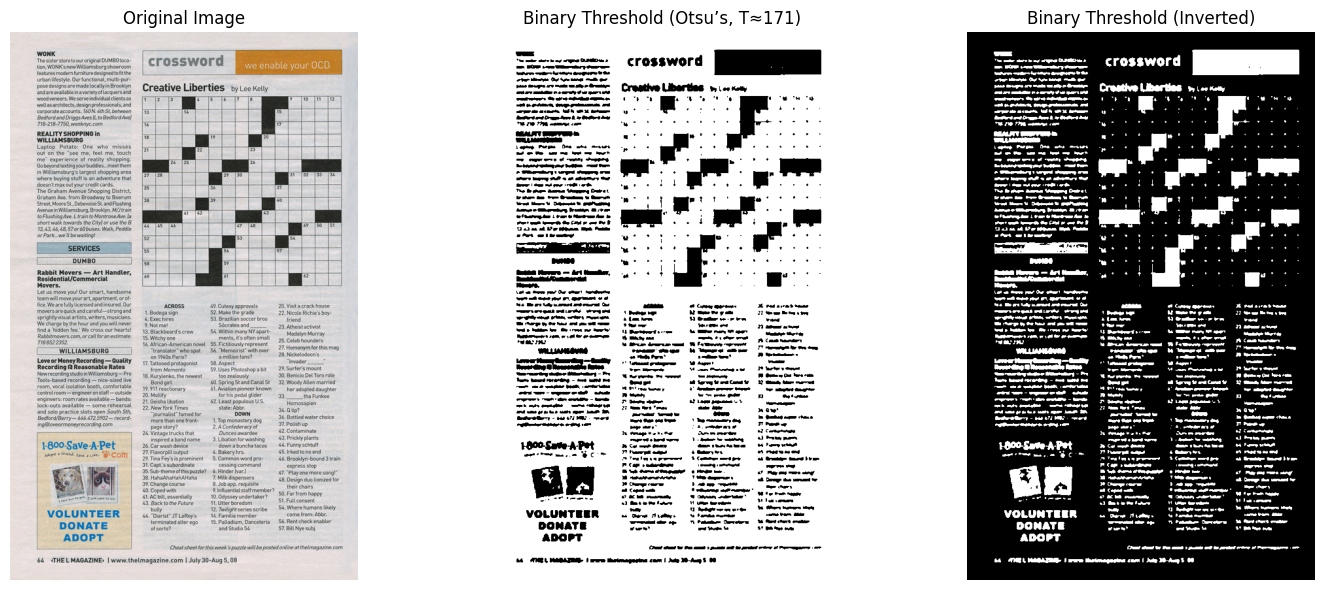

In [8]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/crossword.jpg')

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce text noise
blur = cv.GaussianBlur(gray, (5, 5), 0)

# Otsu Thresholding
_, th_otsu = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# BINARY_INV
_, th_inv = cv.threshold(blur, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# Display results
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(th_otsu, cmap='gray')
plt.title(f"Binary Threshold (Otsu’s, T≈{_:.0f})")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(th_inv, cmap='gray')
plt.title('Binary Threshold (Inverted)')
plt.axis('off')

plt.tight_layout()
plt.show()

I used Otsu's Binary Thresholding to automatically determine the optimal binary segmentation. Compared to fixed global thresholding (v=127) and adaptive thresholding methods, the Otsu approach produced the clearest black-and-white distinction in the crossword image.